## Assignment Lab 04 

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor,
    HistGradientBoostingRegressor
)

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import joblib

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

In [3]:
df = pd.read_csv("AB_NYC_2019.csv")

print("Dataset loaded successfully.")
print("Shape:", df.shape)

Dataset loaded successfully.
Shape: (48895, 16)


In [4]:
print("Dataset Shape:", df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

print("\nFirst 5 Rows:")
display(df.head())

print("\nLast 5 Rows:")
display(df.tail())

print("\nSummary Statistics:")
display(df.describe())

Dataset Shape: (48895, 16)

Column Names:
['id', 'name', 'host_id', 'host_name', 'neighbourhood_group', 'neighbourhood', 'latitude', 'longitude', 'room_type', 'price', 'minimum_nights', 'number_of_reviews', 'last_review', 'reviews_per_month', 'calculated_host_listings_count', 'availability_365']

Data Types:
id                                  int64
name                                  str
host_id                             int64
host_name                             str
neighbourhood_group                   str
neighbourhood                         str
latitude                          float64
longitude                         float64
room_type                             str
price                               int64
minimum_nights                      int64
number_of_reviews                   int64
last_review                           str
reviews_per_month                 float64
calculated_host_listings_count      int64
availability_365                    int64
dtype: object

Fir

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0



Last 5 Rows:


,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
48890,36484665,Charming one bedroom - newly renovated rowhouse,8232441,Sabrina,Brooklyn,Bedford-Stuyvesant,40.67853,-73.94995,Private room,70,2,0,NaN,NaN,2,9
48891,36485057,Affordable room in Bushwick/East Williamsburg,6570630,Marisol,Brooklyn,Bushwick,40.70184,-73.93317,Private room,40,4,0,NaN,NaN,2,36
48892,36485431,Sunny Studio at Historical Neighborhood,23492952,Ilgar & Aysel,Manhattan,Harlem,40.81475,-73.94867,Entire home/apt,115,10,0,NaN,NaN,1,27
48893,36485609,43rd St. Time Square-cozy single bed,30985759,Taz,Manhattan,Hell's Kitchen,40.75751,-73.99112,Shared room,55,1,0,NaN,NaN,6,2
48894,36487245,Trendy duplex in the very heart of Hell's Kitchen,68119814,Christophe,Manhattan,Hell's Kitchen,40.76404,-73.98933,Private room,90,7,0,NaN,NaN,1,23



Summary Statistics:


,id,host_id,latitude,longitude,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
count,4.889500e+04,4.889500e+04,48895.000000,48895.000000,48895.000000,48895.000000,48895.000000,38843.000000,48895.000000,48895.000000
mean,1.901714e+07,6.762001e+07,40.728949,-73.952170,152.720687,7.029962,23.274466,1.373221,7.143982,112.781327
std,1.098311e+07,7.861097e+07,0.054530,0.046157,240.154170,20.510550,44.550582,1.680442,32.952519,131.622289
min,2.539000e+03,2.438000e+03,40.499790,-74.244420,0.000000,1.000000,0.000000,0.010000,1.000000,0.000000
25%,9.471945e+06,7.822033e+06,40.690100,-73.983070,69.000000,1.000000,1.000000,0.190000,1.000000,0.000000
50%,1.967728e+07,3.079382e+07,40.723070,-73.955680,106.000000,3.000000,5.000000,0.720000,1.000000,45.000000
75%,2.915218e+07,1.074344e+08,40.763115,-73.936275,175.000000,5.000000,24.000000,2.020000,2.000000,227.000000
max,3.648724e+07,2.743213e+08,40.913060,-73.712990,10000.000000,1250.000000,629.000000,58.500000,327.000000,365.000000


In [5]:
missing_values = df.isnull().sum()

missing_summary = pd.DataFrame({
    "Missing Values": missing_values,
    "Percentage": (missing_values / len(df)) * 100
})

display(
    missing_summary[
        missing_summary["Missing Values"] > 0
    ].sort_values("Missing Values", ascending=False)
)

,Missing Values,Percentage
reviews_per_month,10052,20.558339
last_review,10052,20.558339
host_name,21,0.042949
name,16,0.032723


In [6]:
print("Price Statistics:")
display(df["price"].describe())

print("\nNumber of zero-price records:")
print((df["price"] == 0).sum())

print("\nPrice Percentiles:")
print("90th percentile :", df["price"].quantile(0.90))
print("95th percentile :", df["price"].quantile(0.95))
print("99th percentile :", df["price"].quantile(0.99))
print("99.5th percentile:", df["price"].quantile(0.995))
print("99.9th percentile:", df["price"].quantile(0.999))

Price Statistics:


count    48895.000000
mean       152.720687
std        240.154170
min          0.000000
25%         69.000000
50%        106.000000
75%        175.000000
max      10000.000000
Name: price, dtype: float64


Number of zero-price records:
11

Price Percentiles:
90th percentile : 269.0
95th percentile : 355.0
99th percentile : 799.0
99.5th percentile: 1000.0
99.9th percentile: 3000.0


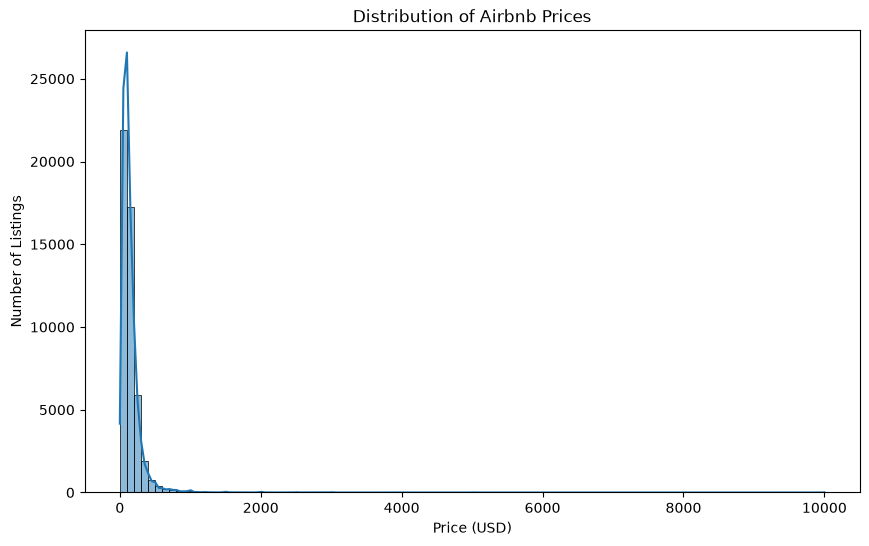

In [7]:
plt.figure(figsize=(10, 6))

sns.histplot(
    df["price"],
    bins=100,
    kde=True
)

plt.title("Distribution of Airbnb Prices")
plt.xlabel("Price (USD)")
plt.ylabel("Number of Listings")

plt.show()

In [8]:
print("Rows before removing zero prices:", len(df))

df = df[df["price"] > 0].copy()

print("Rows after removing zero prices:", len(df))

Rows before removing zero prices: 48895
Rows after removing zero prices: 48884


In [9]:
df["last_review"] = pd.to_datetime(
    df["last_review"],
    errors="coerce"
)

df["last_review_year"] = df["last_review"].dt.year

print("Last Review Year Distribution:")
display(
    df["last_review_year"]
    .value_counts()
    .sort_index()
)

Last Review Year Distribution:


last_review_year
2011.0        7
2012.0       25
2013.0       48
2014.0      199
2015.0     1393
2016.0     2707
2017.0     3204
2018.0     6048
2019.0    25202
Name: count, dtype: int64

In [10]:
year_price = (
    df.groupby("last_review_year")["price"]
    .agg(["count", "mean", "median"])
    .reset_index()
)

display(year_price)

,last_review_year,count,mean,median
0,2011.0,7,169.000000,140.0
1,2012.0,25,158.120000,125.0
2,2013.0,48,256.208333,150.0
3,2014.0,199,160.326633,140.0
4,2015.0,1393,157.204594,110.0
5,2016.0,2707,151.787957,105.0
6,2017.0,3204,135.456929,100.0
7,2018.0,6048,139.014054,100.0
8,2019.0,25202,141.817316,105.0


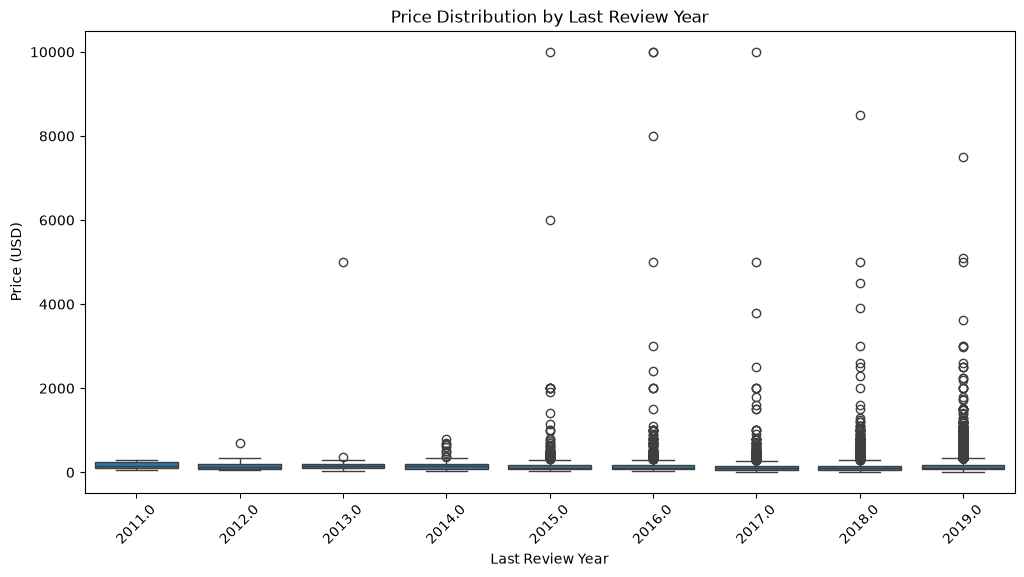

In [11]:
plt.figure(figsize=(12, 6))

sns.boxplot(
    data=df,
    x="last_review_year",
    y="price"
)

plt.title("Price Distribution by Last Review Year")
plt.xlabel("Last Review Year")
plt.ylabel("Price (USD)")

plt.xticks(rotation=45)

plt.show()

In [12]:
columns_to_drop = [
    "id",
    "host_id",
    "name",
    "host_name",
    "last_review"
]

df = df.drop(columns=columns_to_drop)

print("Remaining columns:")
print(df.columns.tolist())

Remaining columns:
['neighbourhood_group', 'neighbourhood', 'latitude', 'longitude', 'room_type', 'price', 'minimum_nights', 'number_of_reviews', 'reviews_per_month', 'calculated_host_listings_count', 'availability_365', 'last_review_year']


In [13]:
missing_after_cleaning = df.isnull().sum()

display(
    pd.DataFrame({
        "Missing Values": missing_after_cleaning,
        "Percentage": (missing_after_cleaning / len(df)) * 100
    })
)

,Missing Values,Percentage
neighbourhood_group,0,0.00000
neighbourhood,0,0.00000
latitude,0,0.00000
longitude,0,0.00000
room_type,0,0.00000
price,0,0.00000
minimum_nights,0,0.00000
number_of_reviews,0,0.00000
reviews_per_month,10051,20.56092
calculated_host_listings_count,0,0.00000


In [14]:
Q1 = df["price"].quantile(0.25)
Q3 = df["price"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[
    (df["price"] < lower_bound) |
    (df["price"] > upper_bound)
]

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)

print("\nPotential outliers:", len(outliers))
print(
    "Percentage of dataset:",
    round((len(outliers) / len(df)) * 100, 2),
    "%"
)

Q1: 69.0
Q3: 175.0
IQR: 106.0
Lower Bound: -90.0
Upper Bound: 334.0

Potential outliers: 2972
Percentage of dataset: 6.08 %


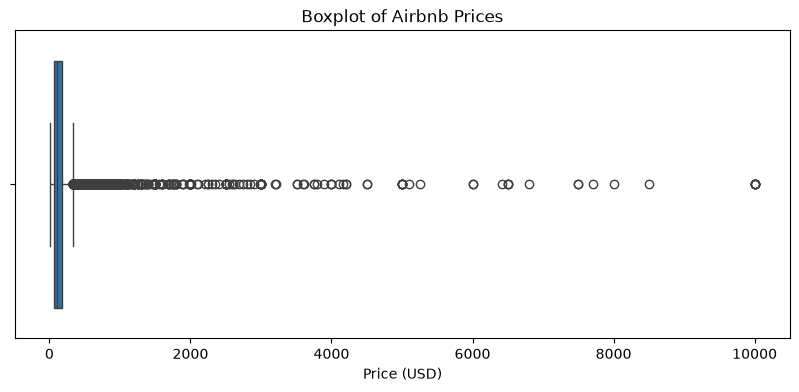

In [15]:
plt.figure(figsize=(10, 4))

sns.boxplot(x=df["price"])

plt.title("Boxplot of Airbnb Prices")
plt.xlabel("Price (USD)")

plt.show()

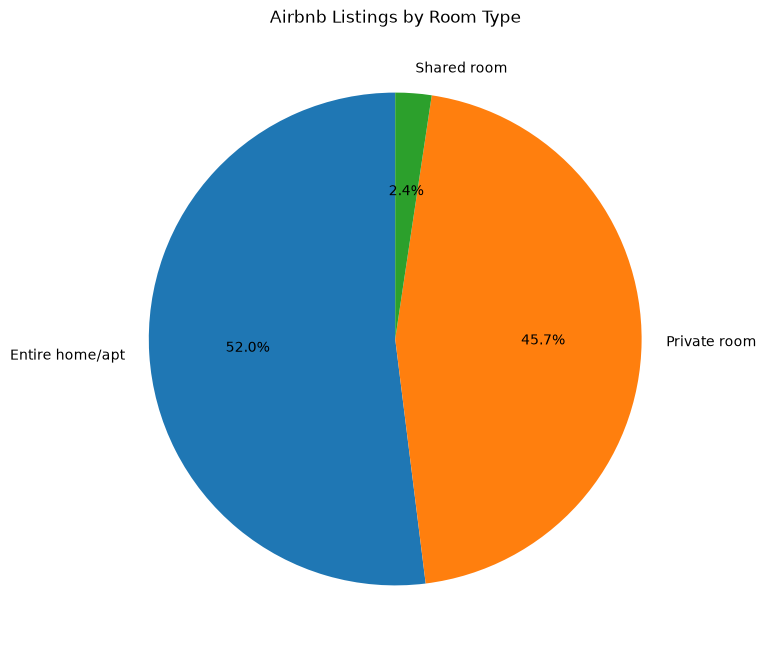

In [16]:
# ==================================================
# ROOM TYPE DISTRIBUTION - PIE CHART
# ==================================================

room_counts = df["room_type"].value_counts()

plt.figure(figsize=(8, 8))

plt.pie(
    room_counts.values,
    labels=room_counts.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Airbnb Listings by Room Type")

plt.show()

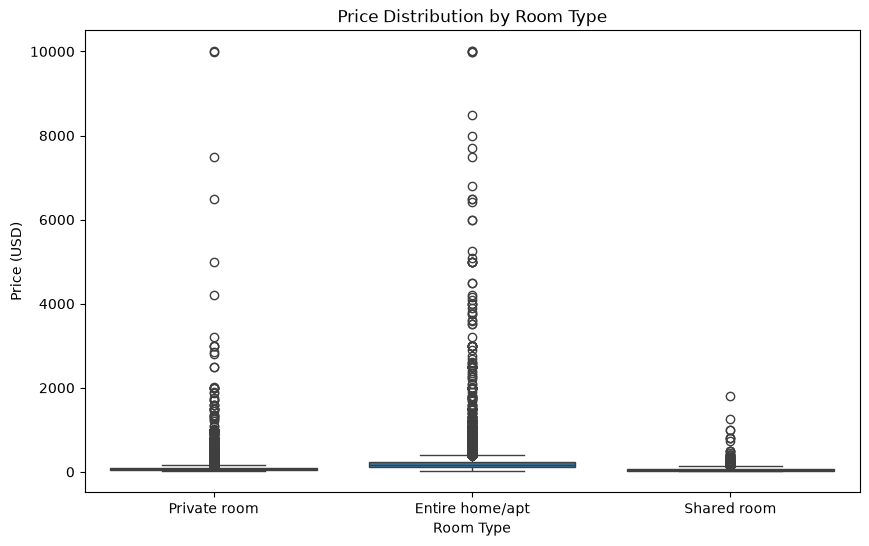

In [17]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x="room_type",
    y="price"
)

plt.title("Price Distribution by Room Type")
plt.xlabel("Room Type")
plt.ylabel("Price (USD)")

plt.show()

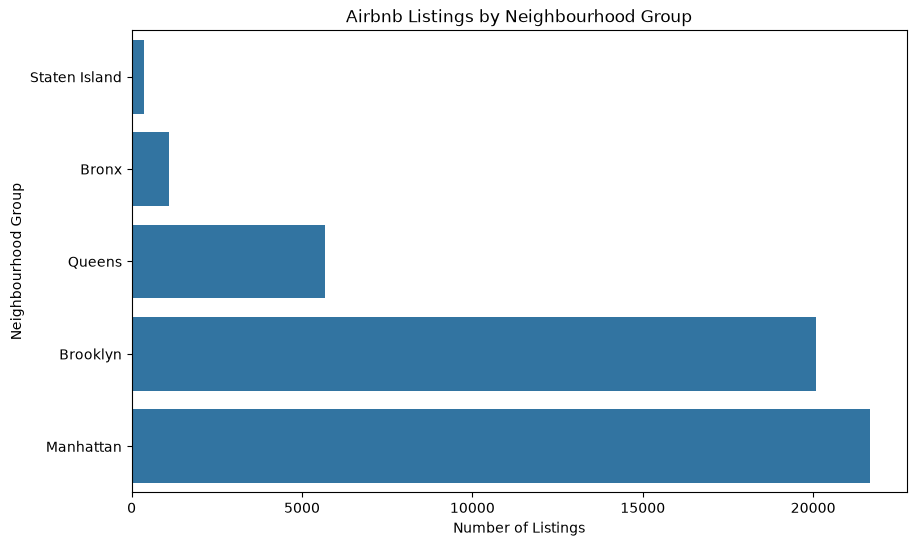

In [18]:
group_counts = df["neighbourhood_group"].value_counts().sort_values()

plt.figure(figsize=(10, 6))

sns.barplot(
    x=group_counts.values,
    y=group_counts.index,
    orient="h"
)

plt.title("Airbnb Listings by Neighbourhood Group")
plt.xlabel("Number of Listings")
plt.ylabel("Neighbourhood Group")

plt.show()

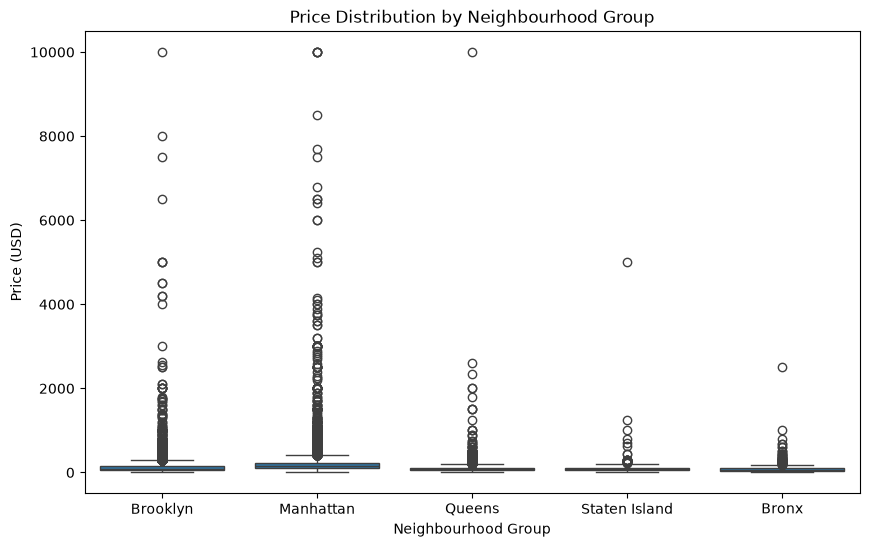

In [19]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x="neighbourhood_group",
    y="price"
)

plt.title("Price Distribution by Neighbourhood Group")
plt.xlabel("Neighbourhood Group")
plt.ylabel("Price (USD)")

plt.show()

In [20]:
print(df["minimum_nights"].describe())

print("\nCounts for selected ranges:")
print("1–3 nights   :", ((df["minimum_nights"] >= 1) & (df["minimum_nights"] <= 3)).sum())
print("4–7 nights   :", ((df["minimum_nights"] >= 4) & (df["minimum_nights"] <= 7)).sum())
print("8–14 nights  :", ((df["minimum_nights"] >= 8) & (df["minimum_nights"] <= 14)).sum())
print("15–30 nights :", ((df["minimum_nights"] >= 15) & (df["minimum_nights"] <= 30)).sum())
print("31–90 nights :", ((df["minimum_nights"] >= 31) & (df["minimum_nights"] <= 90)).sum())
print(">90 nights   :", (df["minimum_nights"] > 90).sum())

count    48884.000000
mean         7.029887
std         20.512224
min          1.000000
25%          1.000000
50%          3.000000
75%          5.000000
max       1250.000000
Name: minimum_nights, dtype: float64

Counts for selected ranges:
1–3 nights   : 32408
4–7 nights   : 9145
8–14 nights  : 1433
15–30 nights : 5151
31–90 nights : 550
>90 nights   : 197


In [21]:
print("Listings with minimum_nights > 30:",
      (df["minimum_nights"] > 30).sum())

print(
    "Percentage:",
    round(
        (df["minimum_nights"] > 30).mean() * 100,
        2
    ),
    "%"
)

Listings with minimum_nights > 30: 747
Percentage: 1.53 %


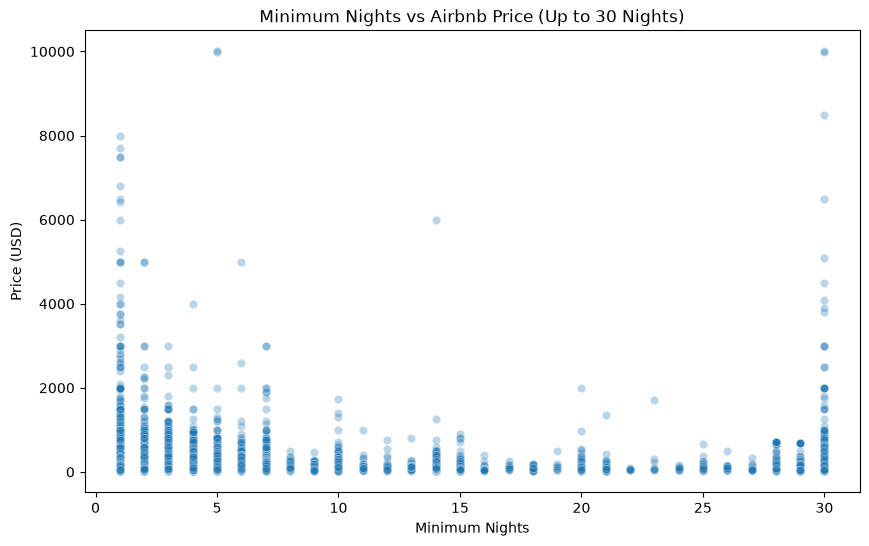

In [22]:
plot_df = df[df["minimum_nights"] <= 30]

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=plot_df,
    x="minimum_nights",
    y="price",
    alpha=0.3
)

plt.title("Minimum Nights vs Airbnb Price (Up to 30 Nights)")
plt.xlabel("Minimum Nights")
plt.ylabel("Price (USD)")

plt.show()

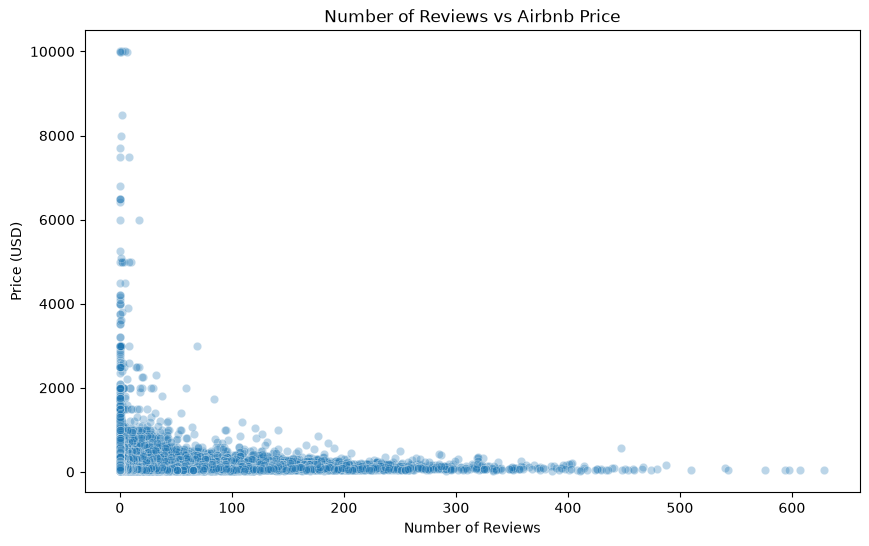

In [23]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="number_of_reviews",
    y="price",
    alpha=0.3
)

plt.title("Number of Reviews vs Airbnb Price")
plt.xlabel("Number of Reviews")
plt.ylabel("Price (USD)")

plt.show()

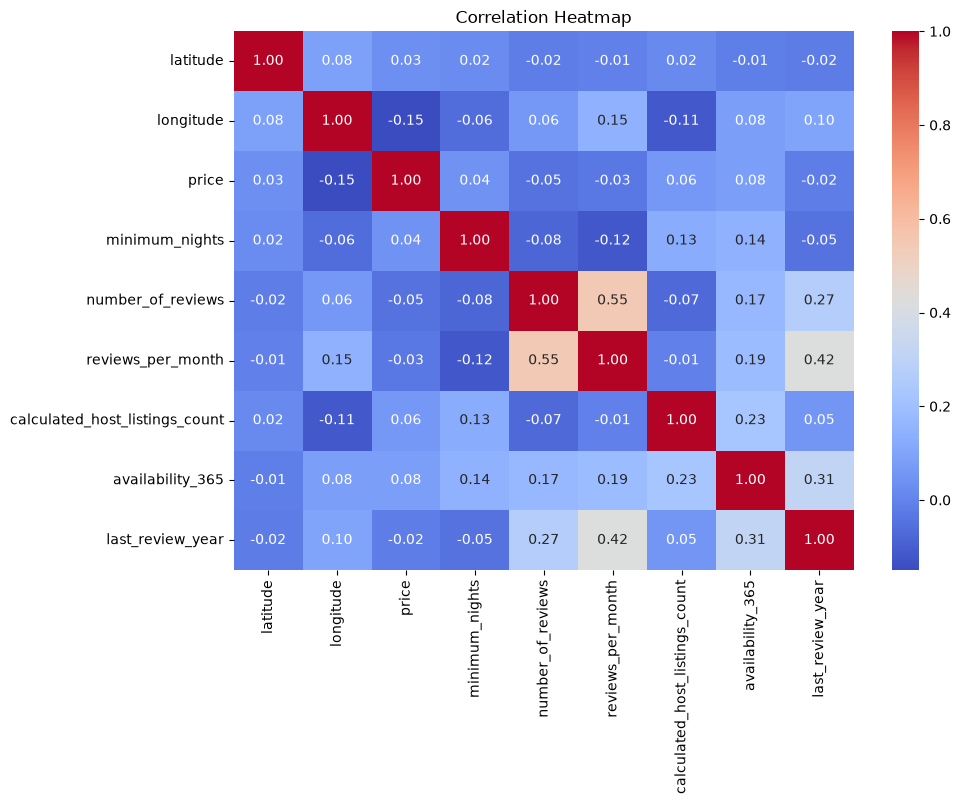

In [24]:
numeric_df = df.select_dtypes(include=np.number)

correlation_matrix = numeric_df.corr()

plt.figure(figsize=(10, 7))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()

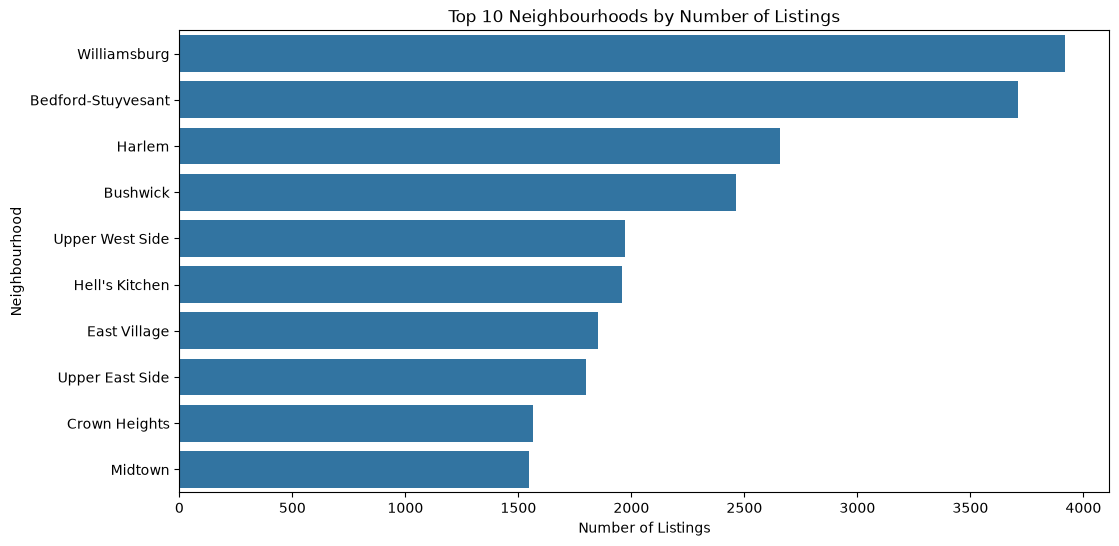

In [25]:
top_neighbourhoods = (
    df["neighbourhood"]
    .value_counts()
    .head(10)
)

plt.figure(figsize=(12, 6))

sns.barplot(
    x=top_neighbourhoods.values,
    y=top_neighbourhoods.index
)

plt.title("Top 10 Neighbourhoods by Number of Listings")
plt.xlabel("Number of Listings")
plt.ylabel("Neighbourhood")

plt.show()

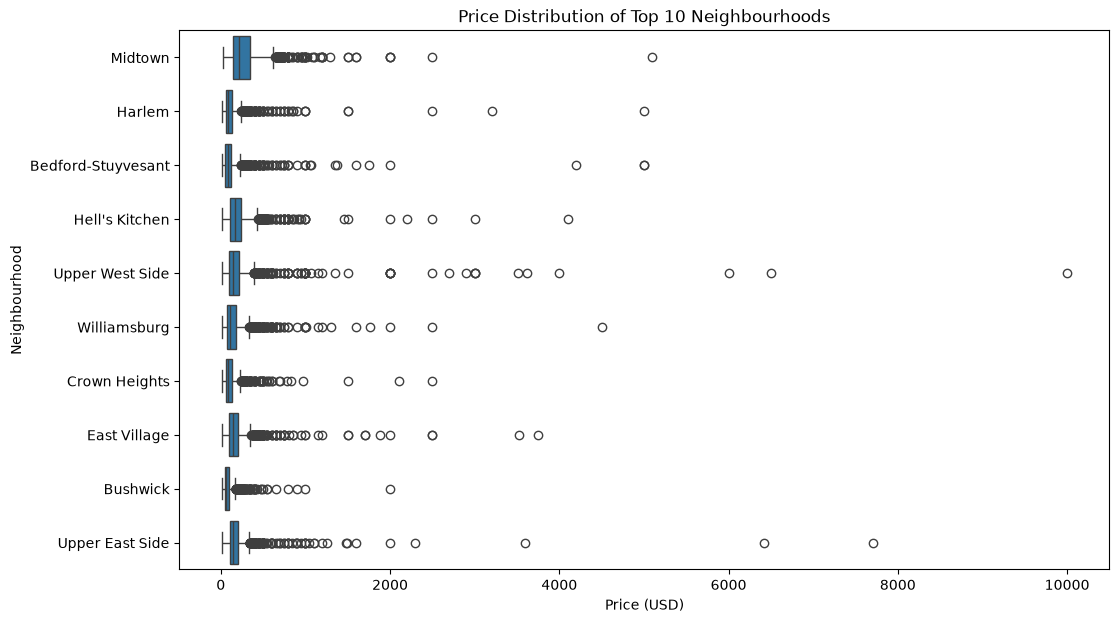

In [26]:
top_10_names = top_neighbourhoods.index

top_neighbourhood_df = df[
    df["neighbourhood"].isin(top_10_names)
]

plt.figure(figsize=(12, 7))

sns.boxplot(
    data=top_neighbourhood_df,
    x="price",
    y="neighbourhood"
)

plt.title("Price Distribution of Top 10 Neighbourhoods")
plt.xlabel("Price (USD)")
plt.ylabel("Neighbourhood")

plt.show()

In [27]:
numeric_features = [
    "latitude",
    "longitude",
    "minimum_nights",
    "number_of_reviews",
    "reviews_per_month",
    "calculated_host_listings_count",
    "availability_365"
]

categorical_features = [
    "neighbourhood_group",
    "neighbourhood",
    "room_type"
]

model_features = numeric_features + categorical_features

X = df[model_features]
y = df["price"]

print("Feature columns:")
print(model_features)

print("\nX shape:", X.shape)
print("y shape:", y.shape)

Feature columns:
['latitude', 'longitude', 'minimum_nights', 'number_of_reviews', 'reviews_per_month', 'calculated_host_listings_count', 'availability_365', 'neighbourhood_group', 'neighbourhood', 'room_type']

X shape: (48884, 10)
y shape: (48884,)


In [28]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training features:", X_train.shape)
print("Testing features:", X_test.shape)

print("Training target:", y_train.shape)
print("Testing target:", y_test.shape)

Training features: (39107, 10)
Testing features: (9777, 10)
Training target: (39107,)
Testing target: (9777,)


In [29]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

print("Preprocessing pipeline created successfully.")

Preprocessing pipeline created successfully.


In [30]:
lr_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LinearRegression())
])

lr_model.fit(X_train, y_train)

y_pred_lr = lr_model.predict(X_test)

mae_lr = mean_absolute_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2_lr = r2_score(y_test, y_pred_lr)

print("Linear Regression")
print("MAE :", mae_lr)
print("RMSE:", rmse_lr)
print("R²  :", r2_lr)

Linear Regression
MAE : 70.74068617256036
RMSE: 186.0980085943931
R²  : 0.13496571135426594


In [31]:
dt_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", DecisionTreeRegressor(
        random_state=42
    ))
])

dt_model.fit(X_train, y_train)

y_pred_dt = dt_model.predict(X_test)

mae_dt = mean_absolute_error(y_test, y_pred_dt)
rmse_dt = np.sqrt(mean_squared_error(y_test, y_pred_dt))
r2_dt = r2_score(y_test, y_pred_dt)

print("Decision Tree Regressor")
print("MAE :", mae_dt)
print("RMSE:", rmse_dt)
print("R²  :", r2_dt)

Decision Tree Regressor
MAE : 87.95632607139204
RMSE: 299.6482635102206
R²  : -1.2427114557336414


In [32]:
rf_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(
        n_estimators=100,
        max_depth=15,
        random_state=42,
        n_jobs=-1
    ))
])

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest Regressor")
print("MAE :", mae_rf)
print("RMSE:", rmse_rf)
print("R²  :", r2_rf)

Random Forest Regressor
MAE : 65.80403193306647
RMSE: 195.12459643496663
R²  : 0.04901447494755484


In [33]:
initial_results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "MAE": [
        mae_lr,
        mae_dt,
        mae_rf
    ],
    "RMSE": [
        rmse_lr,
        rmse_dt,
        rmse_rf
    ],
    "R²": [
        r2_lr,
        r2_dt,
        r2_rf
    ]
})

display(initial_results)

,Model,MAE,RMSE,R²
0,Linear Regression,70.740686,186.098009,0.134966
1,Decision Tree,87.956326,299.648264,-1.242711
2,Random Forest,65.804032,195.124596,0.049014


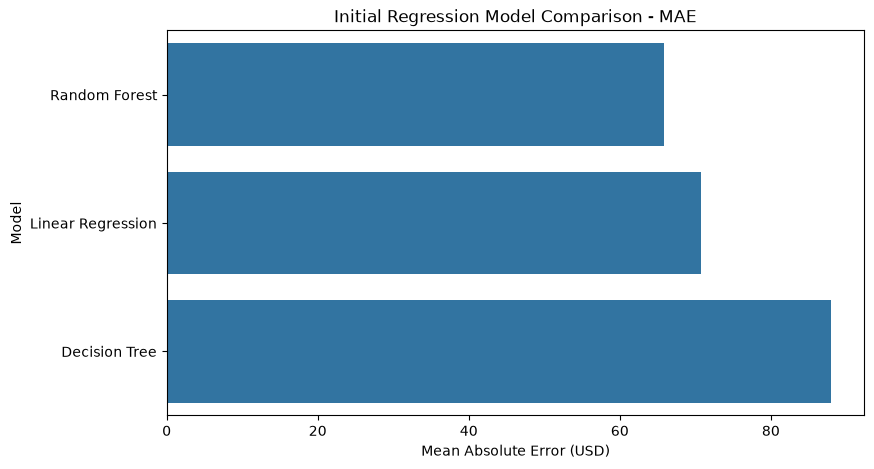

In [34]:
plt.figure(figsize=(9, 5))

mae_results = initial_results.sort_values("MAE")

sns.barplot(
    data=mae_results,
    x="MAE",
    y="Model",
    orient="h"
)

plt.title("Initial Regression Model Comparison - MAE")
plt.xlabel("Mean Absolute Error (USD)")
plt.ylabel("Model")

plt.show()

In [35]:
y_train_log = np.log1p(y_train)

print("Original target mean:", y_train.mean())
print("Log-transformed target mean:", y_train_log.mean())

Original target mean: 153.17907280026594
Log-transformed target mean: 4.738506253692125


In [36]:
rf_log_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(
        n_estimators=100,
        max_depth=15,
        random_state=42,
        n_jobs=-1
    ))
])

rf_log_model.fit(X_train, y_train_log)

y_pred_log = rf_log_model.predict(X_test)

# Convert predictions back to original price scale
y_pred_rf_log = np.expm1(y_pred_log)

mae_rf_log = mean_absolute_error(
    y_test,
    y_pred_rf_log
)

rmse_rf_log = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred_rf_log
    )
)

r2_rf_log = r2_score(
    y_test,
    y_pred_rf_log
)

print("Random Forest with Log Target")
print("MAE :", mae_rf_log)
print("RMSE:", rmse_rf_log)
print("R²  :", r2_rf_log)

Random Forest with Log Target
MAE : 55.9939453081608
RMSE: 175.94252236252106
R²  : 0.22680061734640766


In [37]:
rf_comparison = pd.DataFrame({
    "Model": [
        "Random Forest",
        "Random Forest + Log Target"
    ],
    "MAE": [
        mae_rf,
        mae_rf_log
    ],
    "RMSE": [
        rmse_rf,
        rmse_rf_log
    ],
    "R²": [
        r2_rf,
        r2_rf_log
    ]
})

display(rf_comparison)

,Model,MAE,RMSE,R²
0,Random Forest,65.804032,195.124596,0.049014
1,Random Forest + Log Target,55.993945,175.942522,0.226801


In [38]:
from sklearn.model_selection import RandomizedSearchCV

param_grid = {
    "model__n_estimators": [100, 150, 200],
    "model__max_depth": [10, 15, 20, 25],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4]
}

rf_random_search = RandomizedSearchCV(
    estimator=rf_log_model,
    param_distributions=param_grid,
    n_iter=10,
    cv=3,
    scoring="r2",
    random_state=42,
    n_jobs=-1,
    verbose=1
)

rf_random_search.fit(X_train, y_train_log)

print("Best Parameters:")
print(rf_random_search.best_params_)

print("\nBest CV R²:")
print(rf_random_search.best_score_)

Fitting 3 folds for each of 10 candidates, totalling 30 fits
Best Parameters:
{'model__n_estimators': 200, 'model__min_samples_split': 5, 'model__min_samples_leaf': 4, 'model__max_depth': 20}

Best CV R²:
0.6033665854394253


In [39]:
best_rf_log = rf_random_search.best_estimator_

y_pred_tuned_log = best_rf_log.predict(X_test)

y_pred_tuned = np.expm1(y_pred_tuned_log)

mae_tuned = mean_absolute_error(
    y_test,
    y_pred_tuned
)

rmse_tuned = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred_tuned
    )
)

r2_tuned = r2_score(
    y_test,
    y_pred_tuned
)

print("Tuned Random Forest with Log Target")
print("MAE :", mae_tuned)
print("RMSE:", rmse_tuned)
print("R²  :", r2_tuned)

Tuned Random Forest with Log Target
MAE : 55.663483746834096
RMSE: 179.09557591217893
R²  : 0.19883939350916968


In [40]:
# ==================================================
# GRADIENT BOOSTING WITH LOG TARGET
# ==================================================

gb_log_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", GradientBoostingRegressor(
        n_estimators=100,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    ))
])

gb_log_model.fit(X_train, y_train_log)

y_pred_gb_log = gb_log_model.predict(X_test)

y_pred_gb = np.expm1(y_pred_gb_log)

mae_gb = mean_absolute_error(y_test, y_pred_gb)
rmse_gb = np.sqrt(mean_squared_error(y_test, y_pred_gb))
r2_gb = r2_score(y_test, y_pred_gb)

print("Gradient Boosting with Log Target")
print("MAE :", mae_gb)
print("RMSE:", rmse_gb)
print("R²  :", r2_gb)

Gradient Boosting with Log Target
MAE : 58.185993060120225
RMSE: 186.08726037523965
R²  : 0.13506562977559466


In [41]:
hist_preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),

        (
            "cat",
            Pipeline(steps=[
                (
                    "imputer",
                    SimpleImputer(strategy="most_frequent")
                ),
                (
                    "onehot",
                    OneHotEncoder(
                        handle_unknown="ignore",
                        sparse_output=False
                    )
                )
            ]),
            categorical_features
        )
    ]
)

In [42]:
hist_gb_log_model = Pipeline(steps=[
    ("preprocessor", hist_preprocessor),
    ("model", HistGradientBoostingRegressor(
        max_iter=200,
        learning_rate=0.05,
        max_leaf_nodes=31,
        random_state=42
    ))
])

hist_gb_log_model.fit(
    X_train,
    y_train_log
)

y_pred_hist_log = hist_gb_log_model.predict(X_test)

y_pred_hist = np.expm1(y_pred_hist_log)

mae_hist = mean_absolute_error(
    y_test,
    y_pred_hist
)

rmse_hist = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred_hist
    )
)

r2_hist = r2_score(
    y_test,
    y_pred_hist
)

print("HistGradientBoosting with Log Target")
print("MAE :", mae_hist)
print("RMSE:", rmse_hist)
print("R²  :", r2_hist)

HistGradientBoosting with Log Target
MAE : 56.09555103130253
RMSE: 179.0774133877433
R²  : 0.1990018806190461


In [43]:
final_results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Decision Tree",
        "Random Forest",
        "Random Forest + Log Target",
        "Tuned Random Forest + Log Target",
        "Gradient Boosting + Log Target",
        "HistGradientBoosting + Log Target"
    ],
    "MAE": [
        mae_lr,
        mae_dt,
        mae_rf,
        mae_rf_log,
        mae_tuned,
        mae_gb,
        mae_hist
    ],
    "RMSE": [
        rmse_lr,
        rmse_dt,
        rmse_rf,
        rmse_rf_log,
        rmse_tuned,
        rmse_gb,
        rmse_hist
    ],
    "R²": [
        r2_lr,
        r2_dt,
        r2_rf,
        r2_rf_log,
        r2_tuned,
        r2_gb,
        r2_hist
    ]
})

final_results = final_results.sort_values(
    by="R²",
    ascending=False
).reset_index(drop=True)

display(final_results)

,Model,MAE,RMSE,R²
0,Random Forest + Log Target,55.993945,175.942522,0.226801
1,HistGradientBoosting + Log Target,56.095551,179.077413,0.199002
2,Tuned Random Forest + Log Target,55.663484,179.095576,0.198839
3,Gradient Boosting + Log Target,58.185993,186.087260,0.135066
4,Linear Regression,70.740686,186.098009,0.134966
5,Random Forest,65.804032,195.124596,0.049014
6,Decision Tree,87.956326,299.648264,-1.242711


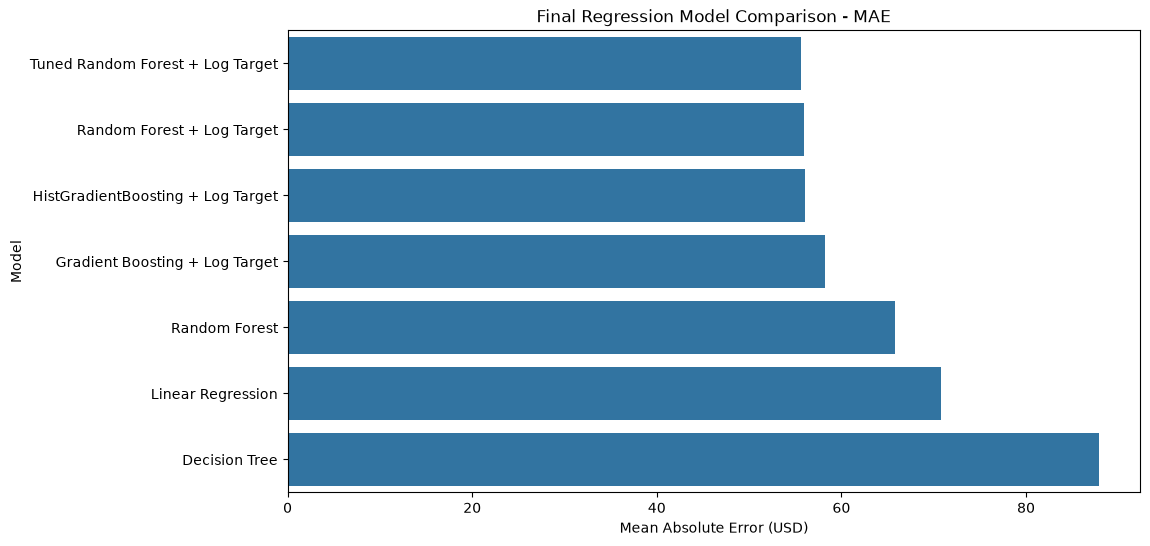

In [44]:
plt.figure(figsize=(11, 6))

plot_results = final_results.sort_values(
    "MAE",
    ascending=True
)

sns.barplot(
    data=plot_results,
    x="MAE",
    y="Model",
    orient="h"
)

plt.title("Final Regression Model Comparison - MAE")
plt.xlabel("Mean Absolute Error (USD)")
plt.ylabel("Model")

plt.show()

In [45]:
best_model_row = final_results.loc[
    final_results["R²"].idxmax()
]

print("Best Model:")
print(best_model_row["Model"])

print("\nBest R²:")
print(best_model_row["R²"])

print("\nBest MAE:")
print(best_model_row["MAE"])

print("\nBest RMSE:")
print(best_model_row["RMSE"])

Best Model:
Random Forest + Log Target

Best R²:
0.22680061734640766

Best MAE:
55.9939453081608

Best RMSE:
175.94252236252106


In [46]:
y_train_pred_log = rf_log_model.predict(X_train)

# Convert back to original price scale
y_train_pred = np.expm1(y_train_pred_log)

# Training metrics
train_mae = mean_absolute_error(y_train, y_train_pred)
train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
train_r2 = r2_score(y_train, y_train_pred)

print("Random Forest + Log Target - Training Performance")
print("MAE :", train_mae)
print("RMSE:", train_rmse)
print("R²  :", train_r2)

print("\nRandom Forest + Log Target - Test Performance")
print("MAE :", mae_rf_log)
print("RMSE:", rmse_rf_log)
print("R²  :", r2_rf_log)

Random Forest + Log Target - Training Performance
MAE : 42.306180069446825
RMSE: 180.61601494813868
R²  : 0.47460703914854685

Random Forest + Log Target - Test Performance
MAE : 55.9939453081608
RMSE: 175.94252236252106
R²  : 0.22680061734640766


In [47]:
overfitting_results = pd.DataFrame({
    "Dataset": ["Training", "Testing"],
    "MAE": [train_mae, mae_rf_log],
    "RMSE": [train_rmse, rmse_rf_log],
    "R²": [train_r2, r2_rf_log]
})

display(overfitting_results)

,Dataset,MAE,RMSE,R²
0,Training,42.306180,180.616015,0.474607
1,Testing,55.993945,175.942522,0.226801


In [48]:
numeric_features_review = [
    "latitude",
    "longitude",
    "minimum_nights",
    "number_of_reviews",
    "reviews_per_month",
    "calculated_host_listings_count",
    "availability_365"
]

categorical_features_review = [
    "neighbourhood_group",
    "neighbourhood",
    "room_type",
    "last_review_year"
]

review_features = (
    numeric_features_review +
    categorical_features_review
)

X_review = df[review_features]
y_review = df["price"]

X_train_review, X_test_review, y_train_review, y_test_review = train_test_split(
    X_review,
    y_review,
    test_size=0.20,
    random_state=42
)

print("Training shape:", X_train_review.shape)
print("Testing shape:", X_test_review.shape)

Training shape: (39107, 11)
Testing shape: (9777, 11)


In [49]:
numeric_transformer_review = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer_review = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor_review = ColumnTransformer(
    transformers=[
        (
            "num",
            numeric_transformer_review,
            numeric_features_review
        ),
        (
            "cat",
            categorical_transformer_review,
            categorical_features_review
        )
    ]
)

In [50]:
y_train_review_log = np.log1p(y_train_review)

rf_review_model = Pipeline(steps=[
    ("preprocessor", preprocessor_review),
    ("model", RandomForestRegressor(
        n_estimators=100,
        max_depth=15,
        random_state=42,
        n_jobs=-1
    ))
])

rf_review_model.fit(
    X_train_review,
    y_train_review_log
)

y_pred_review_log = rf_review_model.predict(
    X_test_review
)

y_pred_review = np.expm1(
    y_pred_review_log
)

In [51]:
mae_review = mean_absolute_error(
    y_test_review,
    y_pred_review
)

rmse_review = np.sqrt(
    mean_squared_error(
        y_test_review,
        y_pred_review
    )
)

r2_review = r2_score(
    y_test_review,
    y_pred_review
)

print("Random Forest + Log Target + Last Review Year")
print("MAE :", mae_review)
print("RMSE:", rmse_review)
print("R²  :", r2_review)

Random Forest + Log Target + Last Review Year
MAE : 55.81272702688127
RMSE: 176.1538917530145
R²  : 0.22494172787317135


In [55]:
final_model = rf_review_model

print("Final Model: Random Forest + Log Target + Last Review Year")

Final Model: Random Forest + Log Target + Last Review Year


In [56]:
joblib.dump(
    final_model,
    "airbnb_price_pipeline.pkl"
)

print("Final pipeline saved successfully.")

Final pipeline saved successfully.
